In [2]:
!python train_yolo_from_tarballs.py

[INFO] Resuming from batch index: 0
✅ All batches processed.


In [1]:
import zipfile
import requests
import cv2
import matplotlib.pyplot as plt
import glob 
import random
import os
from ultralytics import YOLO
import pandas as pd
import torch


## Visualize Images from the Dataset

In [2]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
def yolobbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [3]:
def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalizeA
    # the bounding box coordinates
    h, w, _ = image.shape
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolobbox(box)
        # Denormalize the coordinates.
        xmin = int(x1*w)
        ymin = int(y1*h)
        xmax = int(x2*w)
        ymax = int(y2*h)

        thickness = max(1, int(w/275))
                
        cv2.rectangle(
            image, 
            (xmin, ymin), (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )
    return image

In [4]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    all_images = []
    all_images.extend(glob.glob(image_paths+'/*.png'))
    all_images.extend(glob.glob(image_paths+'/*.PNG'))
    
    all_images.sort()

    num_images = len(all_images)
    
    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0,num_images-1)
        image_name = all_images[j]
        image_name = '.'.join(image_name.split(os.path.sep)[-1].split('.')[:-1])
        image = cv2.imread(all_images[j])
        with open(os.path.join(label_paths, image_name+'.txt'), 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()

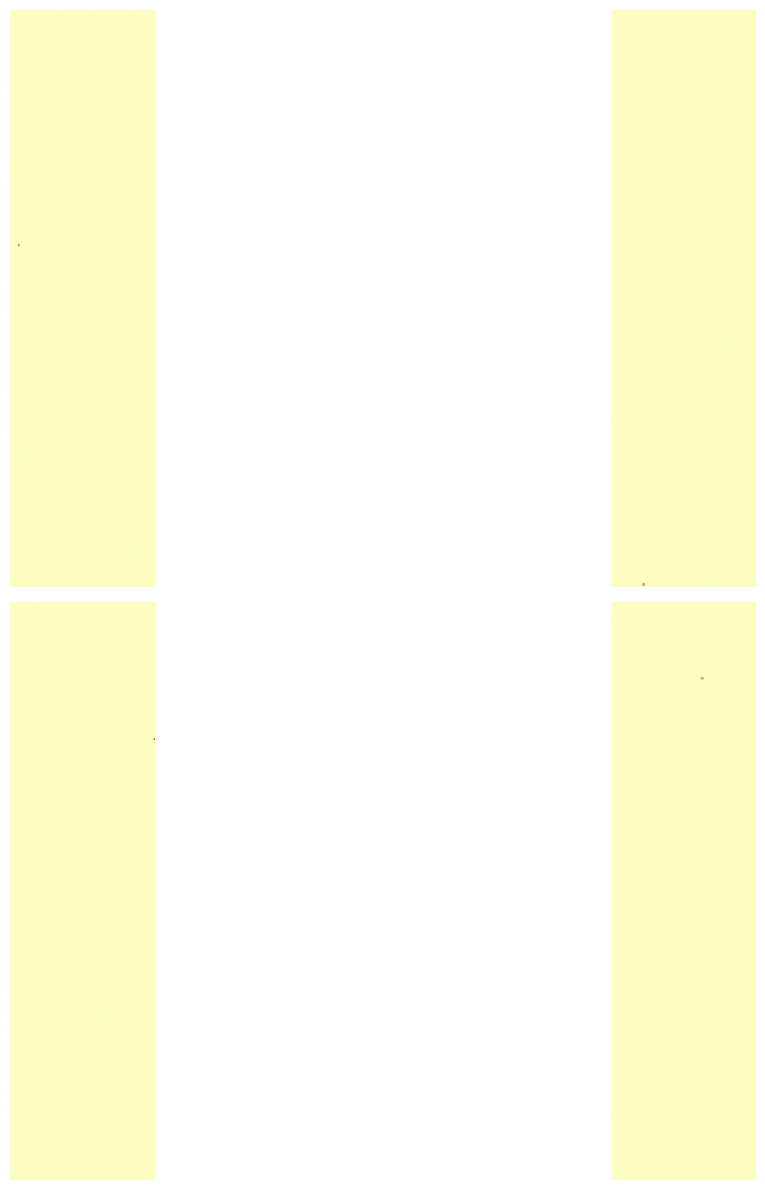

In [5]:
# Visualize a few training images.
plot(
    image_paths='/uscms/home/azhou/nobackup/sahi/train/images/', 
    label_paths='/uscms/home/azhou/nobackup/sahi/train/labels/',
    num_samples=4,
)

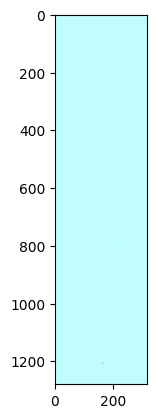

In [6]:
img = cv2.imread("/uscms/home/azhou/nobackup/sahi/train/images/generated_event_9.png")
plt.imshow(img)

## Dataset YAML File

## YOLOv8 Nano Training

In [7]:
# Get the current working directory
os.chdir("/uscms/home/azhou/nobackup/sahi")
print("Current working directory:", os.getcwd())

# Change the directory
os.chdir("/uscms/home/azhou/nobackup/sahi")

# Verify the change
print("New working directory:", os.getcwd())

print(torch.cuda.is_available())

Current working directory: /uscms_data/d3/azhou/sahi
New working directory: /uscms_data/d3/azhou/sahi
True


In [ ]:
#Check mounted dataset

model.data_info('/mnt/combined_dataset/data.yaml')

In [16]:
model = YOLO('yolov8n.pt')

print(model.model.yaml)

#model.conv1 = torch.nn.Conv2d(1, out_channels, kernel_size, stride, padding)
model.model.yaml['ch'] = 3


{'nc': 80, 'depth_multiple': 0.33, 'width_multiple': 0.25, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 3, 'C2f', [128, True]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 6, 'C2f', [256, True]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 6, 'C2f', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 3, 'C2f', [1024, True]], [-1, 1, 'SPPF', [1024, 5]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 3, 'C2f', [512]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 3, 'C2f', [256]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 12], 1, 'Concat', [1]], [-1, 3, 'C2f', [512]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 9], 1, 'Concat', [1]], [-1, 3, 'C2f', [1024]], [[15, 18, 21], 1, 'Detect', ['nc']]], 'ch': 3}


In [7]:
#EPOCHS = 20
from torch.utils.data import DataLoader
#dataloader = DataLoader(dataset='/uscms/home/azhou/nobackup/greyscale/', batch_size=32, shuffle=True, num_workers=0)

model= YOLO('yolov8n.pt')
#model.model.yaml['depth_multiple'] = 0.33
#model.model.yaml['width_multiple'] = 0.05

model.train(data='/mnt/combined_dataset/condor.yaml',
            epochs=20, imgsz=1280, batch=32,
            name='yolov8n_v8_50e', device=0, pretrained=False)
#added device=0 for gpu
#!yolo task=detect mode=train model=yolov8n.pt imgsz=1280 data=sahi_v8.yaml epochs={EPOCHS} batch=32 name=yolov8n_v8_50e device=0 pretrained=False

New https://pypi.org/project/ultralytics/8.3.81 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.75 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/home/azhou/smart-pixels-ml/noiseless_v8.yaml, epochs=20, time=None, patience=100, batch=32, imgsz=1280, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov8n_v8_50e4, exist_ok=False, pretrained=False, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, ret

[W302 02:50:09.661419104 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅


train: Scanning /uscms_data/d3/azhou/noiseless/train/labels.cache... 41235 images, 0 backgrounds, 0 corrupt: 100%|██████████| 41235/41235 [00:00<?, ?it/s]
       1/20      16.3G      3.422      62.64      0.852         24       1280: 100%|██████████| 1289/1289 [13:22<00:00,  1.61it/s]3564/8224 [00:14<00:19, 234.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 129/129 [00:26<00:00,  4.81it/s]

                   all       8224       8224      0.347      0.138      0.154     0.0439



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


IOPub message rate exceeded.3.438      1.525      0.838         25       1280:  20%|██        | 258/1289 [02:41<10:41,  1.61it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Evaluation on Validation Images

In [11]:
!yolo task=detect mode=val model=runs/detect/yolov8n_v8_50e41/weights/best.pt name=yolov8n_eval data=sahi_v8.yaml

Ultralytics 8.3.75 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /uscms_data/d3/azhou/sahi/valid/labels.cache... 8310 images, 0 bac
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all       8310       8310      0.496      0.359      0.468      0.189
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/yolov8n_eval14
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference on Validation Images

In [45]:
!yolo task=detect \
mode=predict \
model=runs/detect/yolov8n_v8_50e25/weights/best.pt \
source=/uscms/home/azhou/nobackup/sahi/valid/images \
imgsz=1280 \
name=yolov8n_v8_50e24_infer1280 \
hide_labels=True

WARNING ⚠️ 'hide_labels' is deprecated and will be removed in in the future. Use 'show_labels' instead.
Ultralytics 8.3.39 🚀 Python-3.10.16 torch-2.0.0.post200 CUDA:0 (NVIDIA A100 80GB PCIe MIG 2g.20gb, 19968MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_1.png: 1280x320 1 event, 44.7ms
image 2/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_10.png: 1280x320 (no detections), 4.6ms
image 3/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_100.png: 1280x320 (no detections), 3.9ms
image 4/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_1000.png: 1280x320 (no detections), 3.9ms
image 5/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_1001.png: 1280x320 (no detections), 3.9ms
image 6/4600 /uscms/home/azhou/nobackup/sahi/valid/images/generated_event_1002.png: 1280x320 (no detections), 3.9ms
image 7/4600 /uscms/ho

image 254/271 /media/sovit/hdd1tbinternal/my_data/Data_Science/Big_Vision/my_blogs/Train-YOLOv8-on-Custom-Dataset-Complete-Tutorial/notebooks/datasets/pothole_dataset_v8/valid/images/img-71_jpg.rf.a66c7ead4152e3634f1d01604a09729f.jpg: 736x1280 13.2ms
image 255/271 /media/sovit/hdd1tbinternal/my_data/Data_Science/Big_Vision/my_blogs/Train-YOLOv8-on-Custom-Dataset-Complete-Tutorial/notebooks/datasets/pothole_dataset_v8/valid/images/img-73_jpg.rf.4d0ebe8bd78382854887c85af26c88b0.jpg: 736x1280 13.3ms
image 256/271 /media/sovit/hdd1tbinternal/my_data/Data_Science/Big_Vision/my_blogs/Train-YOLOv8-on-Custom-Dataset-Complete-Tutorial/notebooks/datasets/pothole_dataset_v8/valid/images/img-74_jpg.rf.b6a7c408ac473908998a74a364e61587.jpg: 736x1280 13.1ms
image 257/271 /media/sovit/hdd1tbinternal/my_data/Data_Science/Big_Vision/my_blogs/Train-YOLOv8-on-Custom-Dataset-Complete-Tutorial/notebooks/datasets/pothole_dataset_v8/valid/images/img-79_jpg.rf.00fb662d8b19ea40165f6597578c18db.jpg: 736x1280 13.

## Visualize Validation Results

In [9]:
# Plot and visualize images in a 2x2 grid.
def visualize(result_dir, num_samples=8):
    """
    Function accepts a list of images and plots
    them in a 2x2 grid.
    """
    plt.figure(figsize=(20, 12))
    image_names = glob.glob(os.path.join(result_dir, '*.jpg'))
    random.shuffle(image_names)
    for i, image_name in enumerate(image_names):
        image = plt.imread(image_name)
        plt.subplot(2, 4, i+1)
        plt.imshow(image)
        plt.axis('off')
        if i == num_samples-1:
            break
    plt.tight_layout()
    plt.show()

In [47]:
visualize('runs/detect/yolov8n_v8_50e25_infer1280/')

<Figure size 2000x1200 with 0 Axes>

#Regular inference
yolov8_model_path = "/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e23/weights/best.pt"

if os.path.exists(yolov8_model_path):
    print("Path exists!")
else:
    print("Path does not exist.")

model = YOLO("/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e23/weights/best.pt")

results = model(["/uscms/home/azhou/nobackup/sahi/valid/images/generated_event_5.png"])

for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    result.show()  # display to screen
    #result.save(filename="result.jpg")  # save to disk
    print('length boxes------', len(boxes.xywh))
    print('boxes-----', boxes.xywh.tolist())
    print('conf------', boxes.conf.item())

# Plotting

## IOU Calculator

In [10]:
def calculate_iou(event_name, model = YOLO("/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e25/weights/best.pt")
):
    """
    calculates IOU between 2 boxes
    
    Args:
        box1:[x1, y1, x2, y2] of first box
        box2:[x1, y1, x2, y2] of second box
        
    Returns:
        IOU
    """

    if not os.path.exists(f"/uscms/home/azhou/nobackup/sahi/valid/labels/{event_name}.txt"):
        print("txt does not exist, continuing execution.")
        return(0.0)

    if not os.path.exists(f"/uscms/home/azhou/nobackup/sahi/valid/images/{event_name}.png"):
        print("img does not exist, continuing execution.")
        return(0.0)
    
    box2 = []
    with open(f"/uscms/home/azhou/nobackup/sahi/valid/labels/{event_name}.txt", "r") as file:
        line = file.readline().strip()
        yolo2_list = [float(value) for value in line.split()]
        box2.append(float(yolo2_list[1]*320))
        box2.append(float(yolo2_list[2]*1280))
        box2.append(float(yolo2_list[1]*320) + float(yolo2_list[3]*320))
        box2.append(float(yolo2_list[2]*1280) + float(yolo2_list[4]*1280))

    results = model([f"/uscms/home/azhou/nobackup/sahi/valid/images/{event_name}.png"], verbose=False)
    for result in results:
        if len(result.boxes.xyxy.tolist()) > 0:
            box1 = result.boxes.xyxy.tolist()[0]
        else:
            print('no boxes')
            box1 = [0,0,0,0]
        
    #Intersection coordinates
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    #Intersectional area
    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)
    
    #Box areas
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    #Union Area
    union_area = box1_area + box2_area - inter_area
    
    #iou
    iou = inter_area / union_area if union_area != 0 else 0
    
    return iou


#for i in range(100):
#    iou_score = calculate_iou(event_name = f"generated_event_{i}")
#    if iou_score != 0:
#        print(iou_score)

#iou_score = calculate_iou(event_name = "generated_event_20")
#print(f"IOU score: {iou_score}")

In [12]:
model = YOLO("/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e25/weights/best.pt")

results = model([f"/uscms/home/azhou/nobackup/sahi/valid/images/generated_event_1.png"], verbose=False)
for result in results:
    if len(result.boxes.xyxy.tolist()) > 0:
        box1 = result.boxes.xyxy.tolist()[0]  # Boxes object for bounding box outputs
        print(box1)

with open(f"/uscms/home/azhou/nobackup/sahi/train/labels/generated_event_1.txt", "r") as file:
# Read the line (assuming there's only one line)
    line = file.readline().strip()
    yolo2_list = [float(value) for value in line.split()]
    box2 = []
    box2.append(float(yolo2_list[1]*320))
    box2.append(float(yolo2_list[2]*1280))
    box2.append(float(yolo2_list[1]*320) + float(yolo2_list[3]*320))
    box2.append(float(yolo2_list[2]*1280) + float(yolo2_list[4]*1280))
    print(box2)

calculate_iou(box1, box2)

[278.7338562011719, 618.6668090820312, 291.4313659667969, 621.4359741210938]
[219.0, 1246.0, 231.0, 1249.0]
txt does not exist, continuing execution.


0.0

## Dictionary processing

In [20]:
import pathlib
import numpy as np

def count_directories(path):
    return len([item for item in pathlib.Path(path).iterdir()])

train_or_valid = 'train'

path_to_check = f'/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/'
directory_count = count_directories(path_to_check)
print("Number of directories:", directory_count)

Number of directories: 47826


In [21]:
def txt_to_dict(filename):
    my_dict = {}
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()  # Remove leading/trailing whitespace
            if line:  # Skip empty lines
                key, value = line.split(':', 1)  # Split on the first colon
                my_dict[key.strip()] = value.strip()  # Store key-value pair
    return my_dict

## Scatterplot

In [20]:
def yolo_plot():
    plot_list = []
    for i in range(directory_count):
        index = i + 1

        if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png").exists():
            results = model([f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png"], verbose=False)
            for result in results:
                boxes = result.boxes  # Boxes object for bounding box outputs
        else:
            print("img file does not exist.")
            continue

        if len(boxes.xywh) > 0:
            if len(boxes.xywh) == 1:
                prediction_score = boxes.conf.item()
            elif len(boxes.xywh) > 1:
                prediction_score = boxes.conf.tolist()[0]
        else:
            prediction_score = 0.
            print("Error: The object_prediction_list is empty or out of range.")

        if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt").exists():
            df_dict = txt_to_dict(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt")
        else:
            print("df file does not exist.")
            continue
    
        with open(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/labels/generated_event_{index}.txt", "r") as file:
        # Read the line (assuming there's only one line)
            line = file.readline().strip()
            yolo2_list = [float(value) for value in line.split()]
            #as a reminder, the format of the txt file is like so yolo2_list = [0.0, x, y, w, h]
            #recall that we reference yolo2 instead of yolo since yolo is a bit offset

        cluster_area = float(df_dict['my_cluster_height']) * float(df_dict['my_cluster_width'])
        x_location = float(yolo2_list[1]*320)
        y_location = float(yolo2_list[2]*1280)
        eh_pairs = float(df_dict['number_eh_pairs'])
        pt_value = float(df_dict['pt'])
        cot_alpha = float(df_dict['cotAlpha'])
        cot_beta = float(df_dict['cotBeta'])
        timeslice_number = float(df_dict['my_timeslice']) + 1.0
        print(timeslice_number)
        
        x_var = cot_alpha
        y_var = cot_beta
        print(i, x_var)
        plot_list.append([x_var,y_var])
        
        ##for last time slices only
        #if int(timeslice_number) == 8:
        #    plot_list.append([x_var,y_var])
    
    x = [p[0] for p in plot_list]
    y = [p[1] for p in plot_list]

    # Create the scatter plot
    plt.scatter(x, y, s=10, edgecolors='darkslategray', facecolors='none', linewidths=1)
    plt.xlabel('X-axis: cotAlpha')
    plt.ylabel('Y-axis: cotBeta ')
    plt.title('cotAlpha vs cotBeta')
    plt.savefig('/home/azhou/smart-pixels-ml/plots/scatter.png')
    plt.show()


3.0
0 -8.478098109341747
6.0
1 2.9491304885688923
1.0
2 -7.476399629107911
7.0
3 3.6866403134509014
6.0
4 -3.8099901934553935
7.0
5 5.159478582752225
8.0
6 7.3675598656764745
6.0
7 7.832468916854167
6.0
8 -7.185739161404199
8.0
9 5.819250710683793
7.0
10 -4.658531309136904
1.0
11 5.278749720590491
7.0
12 3.8301403144428026
8.0
13 1.2166499840757086
5.0
14 -1.0102602872880442
7.0
15 -3.812990299048171
6.0
16 -4.089860730620782
6.0
17 -3.9916691455192295
8.0
18 5.978569885844794
7.0
19 7.589159642966363
7.0
20 6.398830365915836
1.0
21 -2.0546099631879593
5.0
22 -4.174249238802555
4.0
23 -4.881770127379138
6.0
24 -6.058268541831642
6.0
25 -6.663818634847335
2.0
26 -5.99410129391404
7.0
27 6.74605997837612
df file does not exist.
2.0
29 -5.406959301191229
8.0
30 -0.16693909301575094
4.0
31 4.764859492172737
7.0
32 6.725620828992903
2.0
33 6.6997195124785955
5.0
34 6.276459218587563
5.0
35 -3.00433961971445
8.0
36 -3.227421130738666
7.0
37 -4.961389139791513
8.0
38 1.126590122419961
5.0
39 

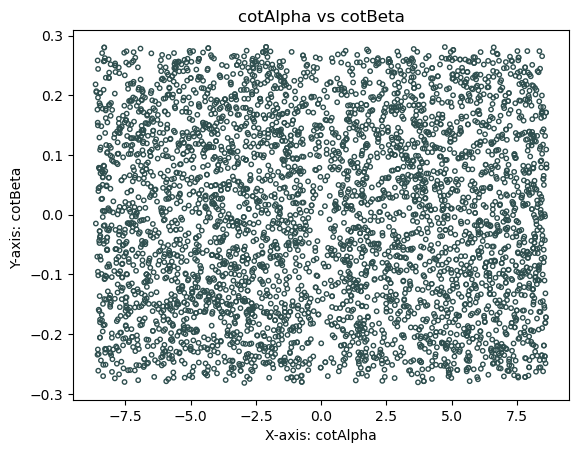

In [21]:
model = YOLO("/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e24/weights/best.pt")

#alpha, beta, eh-pairs,clustersize
yolo_plot()

In [ ]:
...

## 1D Histogram

In [ ]:
def yolo_1Dhist():
    plot_list = []
    for i in range(directory_count):
        index = i + 1

        # if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png").exists():
        #     results = model([f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png"], verbose=False)
        #     for result in results:
        #         boxes = result.boxes  # Boxes object for bounding box outputs
        # else:
        #     print("img file does not exist.")
        #     continue

        # if len(boxes.xywh) > 0:
        #     if len(boxes.xywh) == 1:
        #         prediction_score = boxes.conf.item()
        #     elif len(boxes.xywh) > 1:
        #         prediction_score = boxes.conf.tolist()[0]
        # else:
        #     prediction_score = 0.
        #     print("Error: The object_prediction_list is empty or out of range.")

        if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt").exists():
            df_dict = txt_to_dict(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt")
        else:
            print("df file does not exist.")
            continue
    
        with open(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/labels/generated_event_{index}.txt", "r") as file:
        # Read the line (assuming there's only one line)
            line = file.readline().strip()
            yolo2_list = [float(value) for value in line.split()]
            #as a reminder, the format of the txt file is like so yolo2_list = [0.0, x, y, w, h]
            #recall that we reference yolo2 instead of yolo since yolo is a bit offset

        cluster_area = float(df_dict['my_cluster_height']) * float(df_dict['my_cluster_width'])
        x_location = float(yolo2_list[1]*320)
        y_location = float(yolo2_list[2]*1280)
        eh_pairs = float(df_dict['number_eh_pairs'])
        pt_value = float(df_dict['pt'])
        cot_alpha = float(df_dict['cotAlpha'])
        cot_beta = float(df_dict['cotBeta'])
        timeslice_number = float(df_dict['my_timeslice']) + 1.0
        print(timeslice_number)
        
        x_var = cot_alpha
        print(i, x_var)
        # if prediction_score > 0:
        
        #     #for last time slices only
        #     if int(timeslice_number) == 8:
        #         plot_list.append([x_var,y_var])
    
    x = [p[0] for p in plot_list]

    #Create the 2d histogram plot
    plt.hist(x, bins=(30, 30), cmap='viridis')
    plt.colorbar() 
    plt.xlabel('X-axis: cotAlpha')
    plt.ylabel('Y-axis: Number')
    plt.title('Histogram of cotAlpha')
    plt.savefig('/home/azhou/smart-pixels-ml/plots/zero_1d_hist/cotAlpha_hist.png')
    plt.show()

## 2D Histogram

In [22]:
def yolo_2Dhist():
    plot_list = []
    for i in range(directory_count):
        index = i + 1

        if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png").exists():
            results = model([f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/images/generated_event_{index}.png"], verbose=False)
            for result in results:
                boxes = result.boxes  # Boxes object for bounding box outputs
        else:
            print("img file does not exist.")
            continue

        if len(boxes.xywh) > 0:
            if len(boxes.xywh) == 1:
                prediction_score = boxes.conf.item()
            elif len(boxes.xywh) > 1:
                prediction_score = boxes.conf.tolist()[0]
        else:
            prediction_score = 0.
            print("no boxes found.")

        if pathlib.Path(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt").exists():
            df_dict = txt_to_dict(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/df/df_generated_event_{index}.txt")
        else:
            print("df file does not exist.")
            continue
    
        with open(f"/uscms/home/azhou/nobackup/sahi/{train_or_valid}/labels/generated_event_{index}.txt", "r") as file:
        # Read the line (assuming there's only one line)
            line = file.readline().strip()
            yolo2_list = [float(value) for value in line.split()]
            #as a reminder, the format of the txt file is like so yolo2_list = [0.0, x, y, w, h]
            #recall that we reference yolo2 instead of yolo since yolo is a bit offset

        cluster_area = float(df_dict['my_cluster_height']) * float(df_dict['my_cluster_width'])
        x_location = float(yolo2_list[1]*320)
        y_location = float(yolo2_list[2]*1280)
        eh_pairs = float(df_dict['number_eh_pairs'])
        pt_value = float(df_dict['pt'])
        cot_alpha = float(df_dict['cotAlpha'])
        cot_beta = float(df_dict['cotBeta'])
        timeslice_number = float(df_dict['my_timeslice']) + 1.0
        print(timeslice_number)
        
        x_var = cot_beta
        #y_var = prediction_score
        y_var = prediction_score
        #calculate_iou(event_name = f"generated_event_{index}")
        #if prediction_score > 0:
            #for last time slices only
        if int(timeslice_number) == 8:
            if y_var > 0.0:
                plot_list.append([x_var,y_var])
                print('ADDED')
            else:
                print('.....no.....')
        print('----------------', i, x_var, y_var)
    
    x = [p[0] for p in plot_list]
    y = [p[1] for p in plot_list]

    #Create the 2d histogram plot
    plt.hist2d(x, y, bins=[30, 30], cmap='viridis')
    plt.colorbar() 
    plt.xlabel('X-axis: cotBeta')
    plt.ylabel('Y-axis: Prediction score')
    plt.title('Prediction score vs. cotBeta')
    plt.savefig('/home/azhou/smart-pixels-ml/plots/last_timeslice_plots/lasttime_nonzero_cotBeta_prediction_2dhist.png')
    plt.show()

no boxes found.
6.0
---------------- 0 -0.2707779618006132 0.0
8.0
ADDED
---------------- 1 0.2327051090858431 0.46807822585105896
no boxes found.
4.0
---------------- 2 0.06371356409912272 0.0
img file does not exist.
img file does not exist.
no boxes found.
3.0
---------------- 5 0.19625971653023094 0.0
2.0
---------------- 6 -0.07857489919418449 0.2627577781677246
no boxes found.
6.0
---------------- 7 -0.06511175613252114 0.0
no boxes found.
2.0
---------------- 8 -0.10546913154176243 0.0
no boxes found.
3.0
---------------- 9 -0.18781485555429167 0.0
5.0
---------------- 10 -0.04618999468637268 0.33245357871055603
4.0
---------------- 11 -0.06692109411178246 0.579526960849762
8.0
ADDED
---------------- 12 0.2816270785520184 0.3116140067577362
no boxes found.
6.0
---------------- 13 -0.1885228799842417 0.0
no boxes found.
1.0
---------------- 14 -0.0323737000878276 0.0
3.0
---------------- 15 0.28087615352852496 0.5827987790107727
no boxes found.
6.0
---------------- 16 -0.11882813

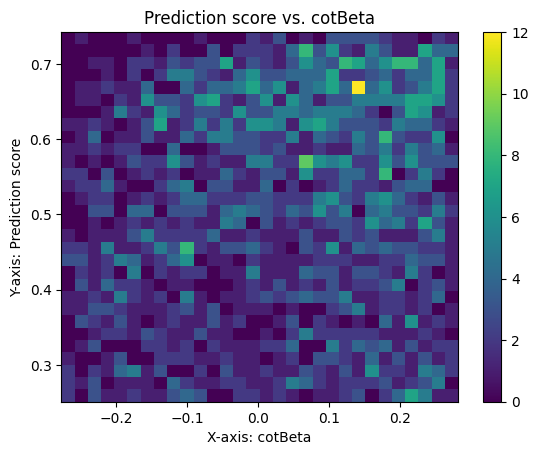

In [23]:
model = YOLO("/uscms/home/azhou/nobackup/sahi/runs/detect/yolov8n_v8_50e24/weights/best.pt")

#alpha, beta, eh-pairs, clustersize
yolo_2Dhist()